In [1]:
import numpy as np
import pandas as pd
import scipy.io as sio
import matplotlib.pyplot as plt
import plotly.graph_objects as go
from plotly.subplots import make_subplots
from numpy.linalg import svd, pinv

%matplotlib widget

# Noisy Data

In [2]:
data = sio.loadmat('ES_Q1_NoisyData.mat')
print(data.keys())

dict_keys(['__header__', '__version__', '__globals__', 'Y_noisy', 'f_noisy'])


In [3]:
f = data['f_noisy']          # input force
Y = data['Y_noisy']          # outputs

print("Shape of f :", f.shape)
print("Shape of Y :", Y.shape)

print(f)
print(Y)

Shape of f : (1000, 1)
Shape of Y : (1000, 5)
[[ 1.78619915e+00]
 [ 5.77055373e-01]
 [-7.98521925e-01]
 [ 2.29299394e+00]
 [-1.37049597e+00]
 [ 7.63455837e-01]
 [-4.65806921e-01]
 [ 1.47097871e+00]
 [-7.69970635e-01]
 [ 7.87419987e-01]
 [-7.78926296e-01]
 [ 3.01343955e-01]
 [ 1.19574256e+00]
 [ 9.63307648e-01]
 [ 6.17176765e-01]
 [-1.36163944e+00]
 [ 1.45686242e+00]
 [ 6.94222396e-01]
 [ 1.21685260e-01]
 [ 3.65851114e-01]
 [-4.46884406e-01]
 [ 1.57763603e+00]
 [ 1.63442075e+00]
 [ 9.11479746e-01]
 [-3.80159204e-01]
 [ 8.56498023e-01]
 [ 2.50796709e-01]
 [ 7.33682798e-01]
 [-6.64914838e-02]
 [-1.20429151e+00]
 [ 3.88233881e-01]
 [-3.20976802e-01]
 [-5.83648575e-01]
 [-6.03498760e-01]
 [-5.41955167e-01]
 [ 1.19206651e+00]
 [-1.10177179e+00]
 [-8.70448915e-01]
 [ 1.54035554e+00]
 [-8.71166900e-01]
 [-4.44580299e-01]
 [ 2.13579184e-01]
 [ 4.21426515e-01]
 [ 2.38247972e-01]
 [-7.74350506e-01]
 [-1.21439455e+00]
 [-2.81948156e-01]
 [ 3.28515950e-01]
 [ 2.51670175e-01]
 [-1.20762031e+00]
 [ 7

In [4]:
f = f.flatten()
Y = np.array(Y)

N = len(f)
n_outputs = Y.shape[1]

print("Number of samples =", N)
print("Number of outputs =", n_outputs)

n_markov = 100

U = np.zeros((N, n_markov))

for i in range(N):
    for j in range(n_markov):
        if i-j >= 0:
            U[i, j] = f[i-j]

print(U.shape)

Number of samples = 1000
Number of outputs = 5
(1000, 100)


In [5]:
Markov = np.zeros((n_outputs, n_markov))

U_pinv = np.linalg.pinv(U)

for r in range(n_outputs):
    
    y = Y[:, r]
    
    m = U_pinv @ y
    
    Markov[r, :] = m

print("Shape of Markov Parameters =", Markov.shape)
print(Markov)

Shape of Markov Parameters = (5, 100)
[[-1.25028500e-02  1.15841867e-02  9.78091127e-02  1.40061612e-01
  -3.01612317e-02 -2.94352473e-01 -2.56858755e-01  7.62894008e-02
   2.94423095e-01  9.07107978e-02 -1.78265811e-01 -1.97685374e-01
   5.37817943e-02  2.09929915e-01  1.04945552e-01 -1.30225320e-02
  -4.92067420e-02  4.04022370e-03  1.58864903e-02 -1.80494243e-03
   1.87550131e-02  1.72797608e-02 -2.42338934e-02 -7.54369119e-02
  -5.84461677e-02  1.49587594e-02  4.90484475e-02  6.03001943e-03
  -5.19361955e-02 -4.17858172e-02  3.53601868e-02  6.63546699e-02
   2.58633782e-02 -4.58223738e-03  2.81490050e-03  3.37609882e-02
   2.23307882e-02 -5.80649282e-03 -1.24531295e-02 -1.50962756e-03
   1.18886576e-02 -1.03991711e-02 -3.49288735e-02 -1.19187594e-02
   4.33175646e-03 -1.00386593e-02 -1.02116557e-02 -8.69855384e-03
   1.55136865e-02  2.76224830e-02  2.66529319e-02 -1.42355949e-02
  -8.22971758e-03  6.59436918e-03  2.45088677e-02  1.30197915e-02
  -8.71294908e-03 -2.05628259e-02  4.0

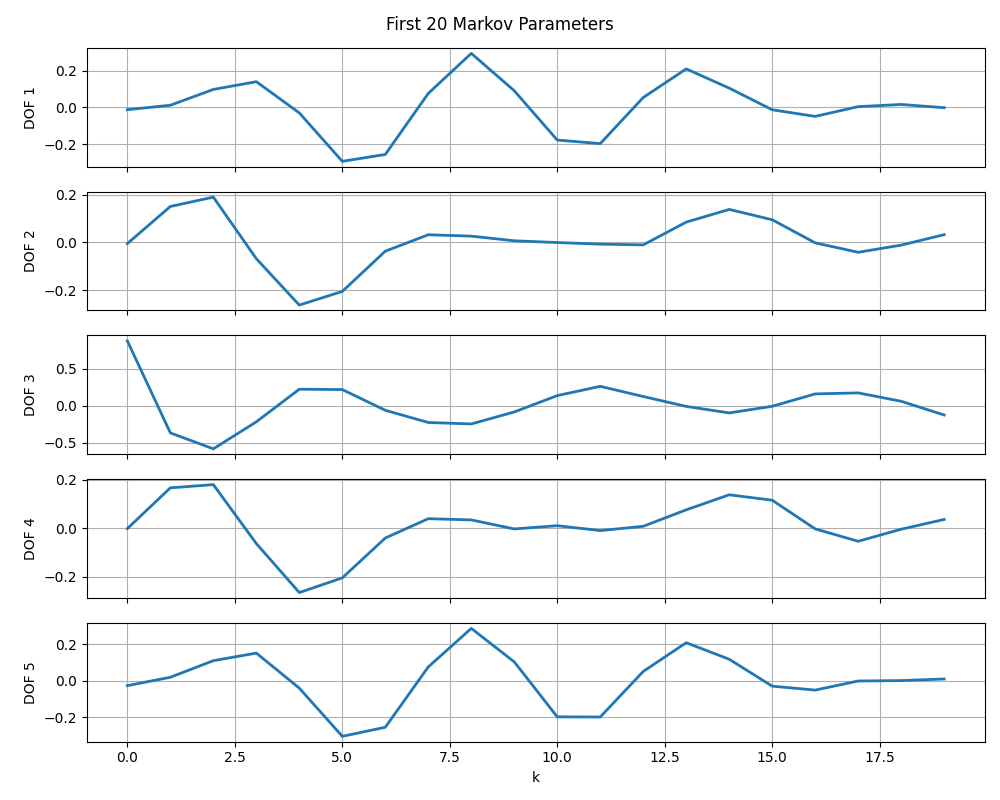

In [20]:
fig, axs = plt.subplots(5,1, figsize=(10,8), sharex=True)

for i in range(5):
    axs[i].plot(Markov[i,:20], linewidth=2)
    axs[i].set_ylabel(f'DOF {i+1}')
    axs[i].grid(True)

axs[-1].set_xlabel('k')
plt.suptitle('First 20 Markov Parameters')
plt.tight_layout()
plt.show()

In [7]:
true_data = sio.loadmat('Q1_TrueMarkovPara.mat')

print(true_data.keys())

dict_keys(['__header__', '__version__', '__globals__', 'mark_para'])


Shape of True Markov = (5, 100)
Shape of Identified Markov = (5, 100)


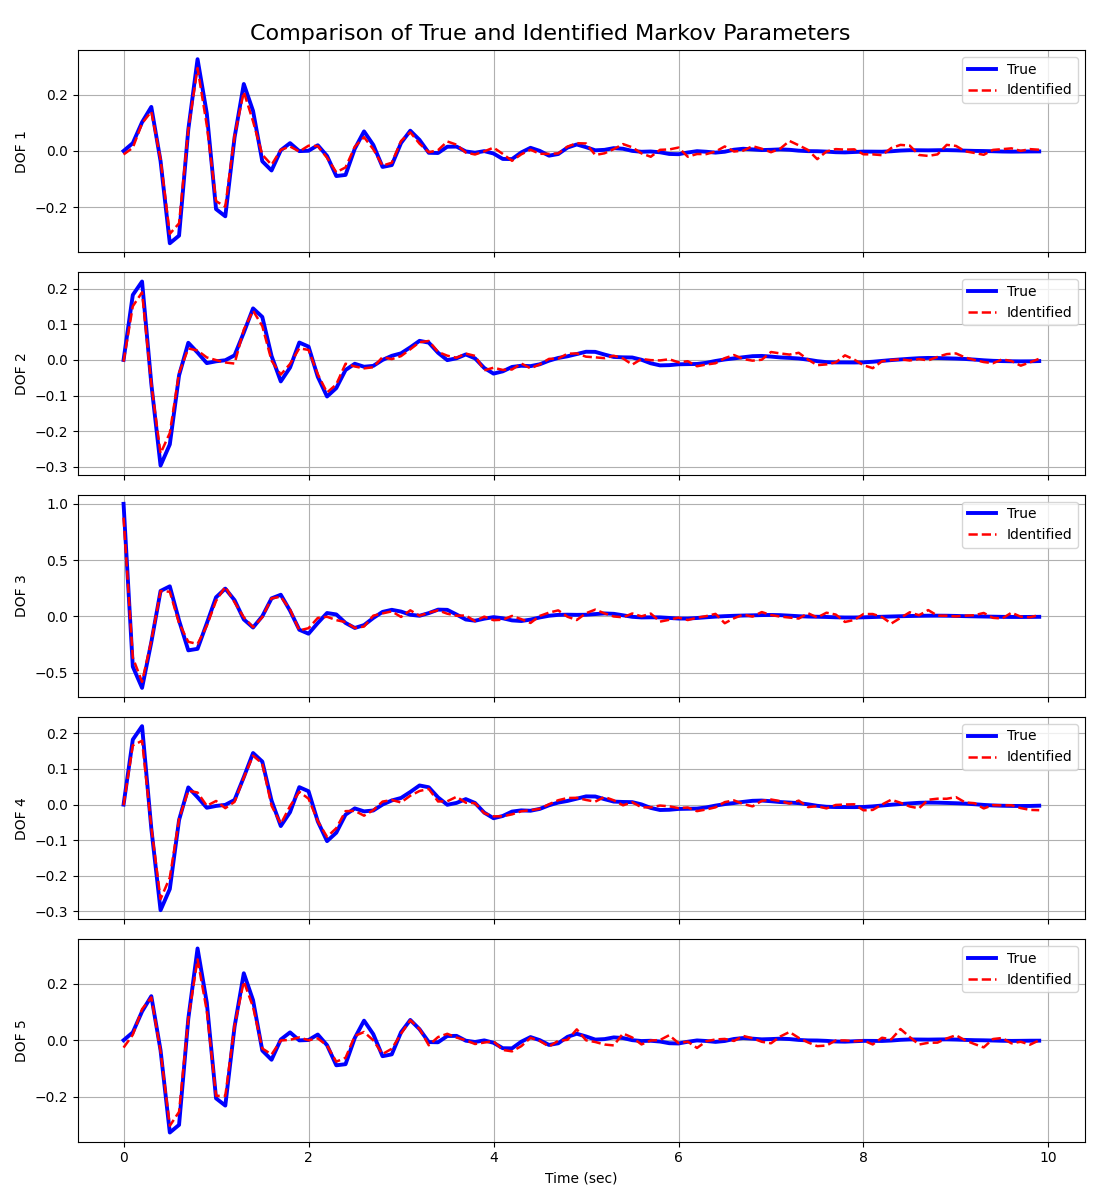

In [8]:
TrueMarkov = true_data['mark_para']

print("Shape of True Markov =", TrueMarkov.shape)
print("Shape of Identified Markov =", Markov.shape)

fs = 10
dt = 1/fs

t = np.arange(100)*dt

fig, axs = plt.subplots(5, 1, figsize=(11,12), sharex=True)

for i in range(5):

    axs[i].plot(t, TrueMarkov[i,:],
                color='blue',
                linewidth=2.8,
                label='True')

    axs[i].plot(t, Markov[i,:],
                color='red',
                linestyle='--',
                linewidth=1.8,
                label='Identified')

    axs[i].set_ylabel(f'DOF {i+1}')
    axs[i].grid(True)
    axs[i].legend(loc='upper right')

axs[-1].set_xlabel('Time (sec)')

fig.suptitle('Comparison of True and Identified Markov Parameters', fontsize=16)

plt.tight_layout()
plt.show()

In [9]:
n_inputs = 1

# rows and columns
r = 40
s = 40

H1 = np.zeros((n_outputs*r, n_inputs*s))
H2 = np.zeros((n_outputs*r, n_inputs*s))

for i in range(r):
    for j in range(s):
        
        # H1 uses Y_(i+j+1)
        H1[i*n_outputs:(i+1)*n_outputs,
           j*n_inputs:(j+1)*n_inputs] = Markov[:, i+j+1].reshape(5,1)
        
        # H2 uses shifted Markov parameters
        H2[i*n_outputs:(i+1)*n_outputs,
           j*n_inputs:(j+1)*n_inputs] = Markov[:, i+j+2].reshape(5,1)

print("H1 shape =", H1.shape)
print("H2 shape =", H2.shape)

U, S, VT = svd(H1, full_matrices=False)

print("Number of singular values =", len(S))

H1 shape = (200, 40)
H2 shape = (200, 40)
Number of singular values = 40


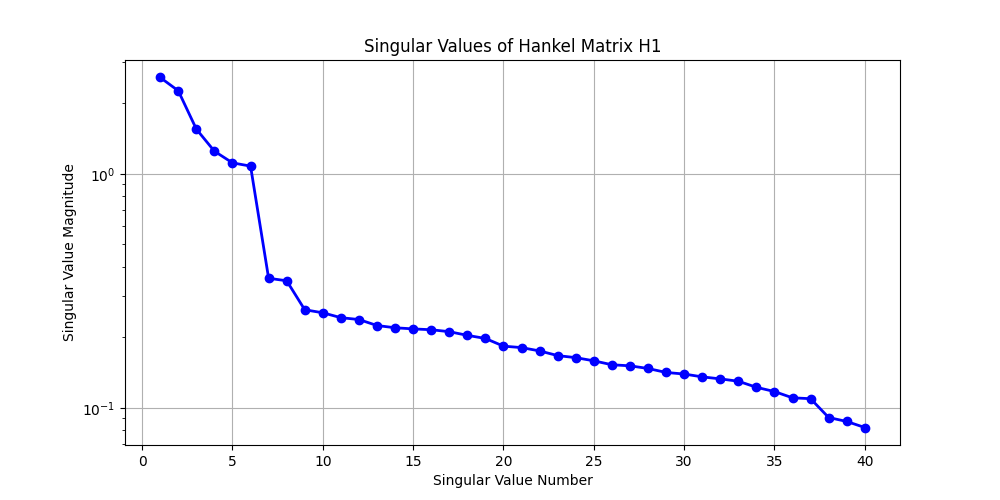

In [10]:
plt.figure(figsize=(10,5))
plt.semilogy(np.arange(1,len(S)+1), S, 'bo-', linewidth=2)
plt.xlabel('Singular Value Number')
plt.ylabel('Singular Value Magnitude')
plt.title('Singular Values of Hankel Matrix H1')
plt.grid(True)
plt.show()

We can see that a steep drop comes after n=6. Hence we truncate U, S and V after 6 entries.

In [11]:
n = 6

U1  = U[:, :n]
S1  = np.diag(S[:n])
VT1 = VT[:n, :]

S_inv_sqrt = np.diag(1/np.sqrt(S[:n]))
S_sqrt     = np.diag(np.sqrt(S[:n]))

A_d = S_inv_sqrt @ U1.T @ H2 @ VT1.T @ S_inv_sqrt

C_d = U1[:n_outputs, :] @ S_sqrt

B_d = S_sqrt @ VT1[:, :n_inputs]

D_d = Markov[:,0].reshape(n_outputs,1)

In [12]:
print("A_d shape =", A_d.shape)
print("B_d shape =", B_d.shape)
print("C_d shape =", C_d.shape)
print("D_d shape =", D_d.shape)

A_d shape = (6, 6)
B_d shape = (6, 1)
C_d shape = (5, 6)
D_d shape = (5, 1)


In [13]:
eigvals, eigvecs = np.linalg.eig(A_d)

s = np.log(eigvals) / dt

idx = np.where(np.imag(s) > 0)[0]

s_sel   = s[idx]
phi_sel = eigvecs[:, idx]

n_modes = len(idx)

print("Identified modes =", n_modes)

freq_Hz = []
zeta = []
ModeShapes = np.zeros((5, n_modes))


for j in range(n_modes):
    
    sj   = s_sel[j]
    phij = phi_sel[:, j]
    
    wn = np.abs(sj)
    fj = wn / (2*np.pi)
    
    zj = -np.real(sj) / wn
    
    psi = C_d @ phij
    
    k = np.argmax(np.abs(psi))
    theta = -np.angle(psi[k])
    
    v = np.real(psi * np.exp(1j*theta))
    
    v = v / np.max(np.abs(v))
    
    freq_Hz.append(fj)
    zeta.append(zj)
    ModeShapes[:,j] = v

Identified modes = 3


In [14]:
freq_Hz = np.array(freq_Hz)
zeta    = np.array(zeta)

for j in range(n_modes):
    print(f"Mode {j+1}")
    print("Frequency (Hz) =", freq_Hz[j])
    print("Damping Ratio =", zeta[j])
    print("Mode Shape =", ModeShapes[:,j])
    print()

Mode 1
Frequency (Hz) = 2.232960825559725
Damping Ratio = 0.0500943728404695
Mode Shape = [ 1.         -0.45828578  0.42167808 -0.46417641  0.98755793]

Mode 2
Frequency (Hz) = 1.702380978040279
Damping Ratio = 0.0832883079422372
Mode Shape = [-0.64784622 -0.40878543  1.         -0.41111069 -0.67357758]

Mode 3
Frequency (Hz) = 0.5409062821302836
Damping Ratio = 0.09985317105590233
Mode Shape = [0.44365356 0.82025277 1.         0.82623423 0.45004119]



In [15]:
true_modal = sio.loadmat('Q1_TrueModalPara.mat')

print(true_modal.keys())

print(true_modal)

dict_keys(['__header__', '__version__', '__globals__', 'damp', 'MS', 'freq'])
{'__header__': b'MATLAB 5.0 MAT-file, Platform: PCWIN64, Created on: Sun Apr 09 17:52:52 2017', '__version__': '1.0', '__globals__': [], 'damp': array([[0.1 , 0.1 , 0.08, 0.08, 0.05]]), 'MS': array([[ 2.81845199e-01, -4.59700843e-01, -5.05936655e-01,
        -8.88073834e-01,  8.15224745e-01],
       [ 5.22720726e-01, -6.27963030e-01, -3.02028137e-01,
         3.25057584e-01, -3.68160356e-01],
       [ 6.11628457e-01, -1.11036572e-17,  7.49390492e-01,
         0.00000000e+00,  2.53622791e-01],
       [ 5.22720726e-01,  6.27963030e-01, -3.02028137e-01,
        -3.25057584e-01, -3.68160356e-01],
       [ 2.81845199e-01,  4.59700843e-01, -5.05936655e-01,
         8.88073834e-01,  8.15224745e-01]]), 'freq': array([[0.54273902, 1.13344657, 1.68616034, 2.18965063, 2.22889936]])}


In [ ]:
f_true = true_modal['freq'].flatten()
zeta_true = true_modal['damp'].flatten()
Phi_true = true_modal['MS']

print("True frequencies shape =", f_true.shape)
print("True damping shape =", zeta_true.shape)
print("True mode shapes shape =", Phi_true.shape)

idx_sort = np.argsort(freq_Hz)

freq_id = freq_Hz[idx_sort]
zeta_id = zeta[idx_sort]
Phi_id  = ModeShapes[:, idx_sort]

print("Identified frequencies =", freq_id)
print("Identified damping =", zeta_id)

True frequencies shape = (5,)
True damping shape = (5,)
True mode shapes shape = (5, 5)
Identified frequencies = [0.54090628 1.70238098 2.23296083]
Identified damping = [0.09985317 0.08328831 0.05009437]


In [17]:
# MAC Function

def MAC(u, v):
    u = np.array(u).reshape(-1,1)
    v = np.array(v).reshape(-1,1)
    
    num = np.abs(u.T @ v)**2
    den = (u.T @ u) * (v.T @ v)
    
    return float(num / den)

In [18]:
results = []

used = []

for i in range(len(freq_id)):
    
    diff = np.abs(f_true - freq_id[i])
    
    for j in used:
        diff[j] = 1e9
    
    jbest = np.argmin(diff)
    used.append(jbest)
    
    ft = f_true[jbest]
    zt = zeta_true[jbest]
    phit = Phi_true[:, jbest]
    
    fi = freq_id[i]
    zi = zeta_id[i]
    phii = Phi_id[:, i]
    
    if np.dot(phii, phit) < 0:
        phii = -phii
    
    err_f = (fi-ft)/ft * 100
    err_z = (zi-zt)/zt * 100
    
    mac_val = MAC(phii, phit)
    
    results.append([
        i+1,           # identified mode no.
        jbest+1,       # matched true mode no.
        fi, ft,
        zi, zt,
        err_f,
        err_z,
        mac_val
    ])

C:\Users\Kushagra\AppData\Local\Temp\ipykernel_17992\37750654.py:10: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  return float(num / den)


In [19]:
columns = [
    'Identified Mode',
    'True Mode',
    'Identified f (Hz)',
    'True f (Hz)',
    'Identified zeta',
    'True zeta',
    '% Error f',
    '% Error zeta',
    'MAC'
]

df = pd.DataFrame(results, columns=columns)

df

,Identified Mode,True Mode,Identified f (Hz),True f (Hz),Identified zeta,True zeta,% Error f,% Error zeta,MAC
0,1,1,0.540906,0.542739,0.099853,0.10,-0.337684,-0.146829,0.999686
1,2,3,1.702381,1.686160,0.083288,0.08,0.961987,4.110385,0.999657
2,3,5,2.232961,2.228899,0.050094,0.05,0.182218,0.188746,0.995266
